# Domain Randomization
- BaseDomainRandomizer
- VanillaDomainRandomizer
- CurriculumDomainRandomizer

## 1) BaseDomainRandomizer
It is just the base class. 

In [1]:
from domain_randomization.methods.base_randomizer import BaseDomainRandomizer

In [2]:
# you cannot instantiate the base class
dr = BaseDomainRandomizer()

TypeError: Can't instantiate abstract class BaseDomainRandomizer with abstract methods add, sample, summary

## 2) VanillaDomainRandomizer
The simples domain randomization: you provide distributions and distribution parameters; it samples from those distributions.

In [3]:
from domain_randomization.methods.vanilla_randomizer import VanillaDomainRandomizer

import matplotlib.pyplot as plt
import numpy as np

In [4]:
dr = VanillaDomainRandomizer(identifier=1)

### Add parameters to randomize using .add()
Below we would like to randomize 4 simulation parameters `arm_length`, `young_modulus`, the gravitational acceleration `gravity_vector`, and the simulation time-step `dt`. Each call to `add()` requires:

- an arbitrary parameter name (e.g., 'arm_length')
- a distribution type (e.g., `uniform`) and 
- the associated distribution parameters (e.g., the lower bound `low` and upper bound `high`). 

The distributions follow the interface of `numpy` (e.g., `numpy.random.uniform`).

We can arbitrary randomize parameters having any unit measure (e.g., m, m/s$^2$) and dimension (e.g., scalar, vector).

In [5]:
dr.add(parameter_name='arm_length', distribution='uniform', distribution_args=dict(low=0.19, high=0.22))
dr.add(parameter_name='young_modulus', distribution='normal', distribution_args=dict(loc=1.6e6, scale=2e2))
dr.add(parameter_name='gravity_vector', distribution='normal', distribution_args=dict(loc=[0, 0, -9.81], scale=0.1))
dr.add(parameter_name='dt', distribution='choice', distribution_args=dict(a=[2e-4, 1.5e-4], p=[0.9, 0.1]))

### Print an overview of the selected parameters and distributions with .summary()

In [6]:
dr.summary()

╒════════════════╤════════════════╤══════════════════════════════════╕
│ Parameter      │ Distribution   │ Arguments                        │
╞════════════════╪════════════════╪══════════════════════════════════╡
│ arm_length     │ uniform        │ low=0.19 high=0.22               │
├────────────────┼────────────────┼──────────────────────────────────┤
│ young_modulus  │ normal         │ loc=1600000.0 scale=200.0        │
├────────────────┼────────────────┼──────────────────────────────────┤
│ gravity_vector │ normal         │ loc=[0, 0, -9.81] scale=0.1      │
├────────────────┼────────────────┼──────────────────────────────────┤
│ dt             │ choice         │ a=[0.0002, 0.00015] p=[0.9, 0.1] │
╘════════════════╧════════════════╧══════════════════════════════════╛


### Sample new parameters with .sample()
Everytime an episode starts and you want to reset the environment, you can sample new parameters with `sample`, which will return a dictionary.

In [7]:
n_episodes = 1000

dr.init_history()
for i in range(n_episodes):
    sampled_parameters = dr.sample()

dr_history = dr.dr_history

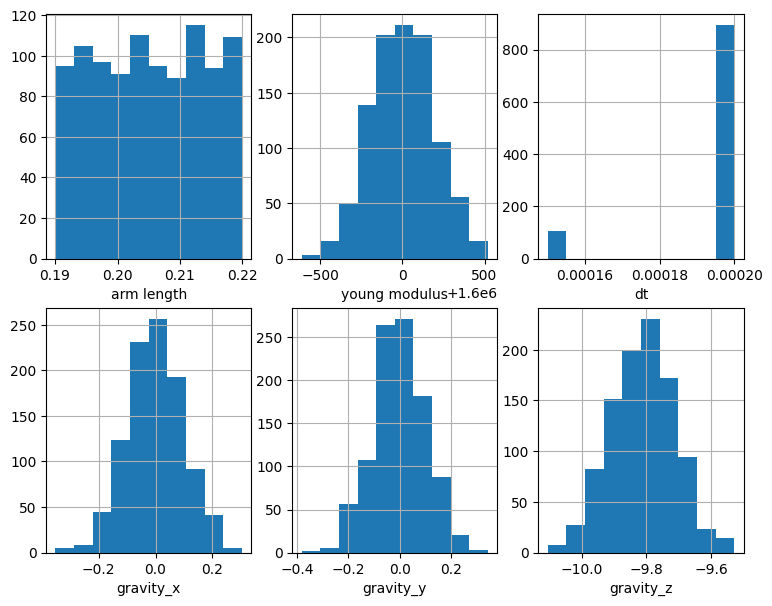

In [8]:
# plot parameters and check that the distributions are as expected
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(9,7))

# arm length
axes[0][0].hist(x=dr_history['arm_length'])
axes[0][0].set_xlabel('arm length')

# young modulus
axes[0][1].hist(x=dr_history['young_modulus'])
axes[0][1].set_xlabel('young modulus')

# dt
axes[0][2].hist(x=dr_history['dt'])
axes[0][2].set_xlabel('dt')

# gravity
axes[1][0].hist(x=np.array(dr_history['gravity_vector'])[:,0])
axes[1][0].set_xlabel('gravity_x')

axes[1][1].hist(x=np.array(dr_history['gravity_vector'])[:,1])
axes[1][1].set_xlabel('gravity_y')

axes[1][2].hist(x=np.array(dr_history['gravity_vector'])[:,2])
axes[1][2].set_xlabel('gravity_z')

for ax in axes.reshape(-1):
    ax.grid(True)

plt.show()

## 3 Curriculum Domain Randomization
It is the extension of VanillaDomainRandomizer.
In addition you define a `ramp_steps` parameter which monitors the degree of curriculum.
After `ramp_steps` episodes, the behavior is the same as VanillaDomainRandomizer.

In practice, the curriculum domain randomization produces wider distributions as training proceeds...

In [9]:
from domain_randomization.methods.curriculum_randomizer import CurriculumDomainRandomizer
import matplotlib.pyplot as plt
import numpy as np

In [10]:
# define two domain randomizers
# ramp_steps=100, so the curriculum will reach the regime after 200 steps
dr1 = CurriculumDomainRandomizer(identifier=1, ramp_steps=200, seed=0)
dr2 = CurriculumDomainRandomizer(identifier=2, ramp_steps=200, seed=0)

In [11]:
dr1.add(parameter_name='arm_length', distribution='uniform', distribution_args=dict(low=0.19, high=0.22))
dr1.add(parameter_name='young_modulus', distribution='normal', distribution_args=dict(loc=1.6, scale=0.2))
dr1.add(parameter_name='gravity_vector', distribution='normal', distribution_args=dict(loc=[0, 0, -9.81], scale=0.1))
#dr.add(parameter_name='dt', distribution='choice', distribution_args=dict(a=[2e-4, 1.5e-4], p=[0.9, 0.1]))

dr2.add(parameter_name='arm_length', distribution='uniform', distribution_args=dict(low=0.19, high=0.22))
dr2.add(parameter_name='young_modulus', distribution='normal', distribution_args=dict(loc=1.6, scale=0.2))

In [12]:
n_episodes = 300

dr1.init_history()
dr2.init_history()

for i in range(n_episodes):
    sampled_parameters = dr1.sample()
    sampled_parameters = dr2.sample()

dr1_history = dr1.dr_history
dr2_history = dr2.dr_history

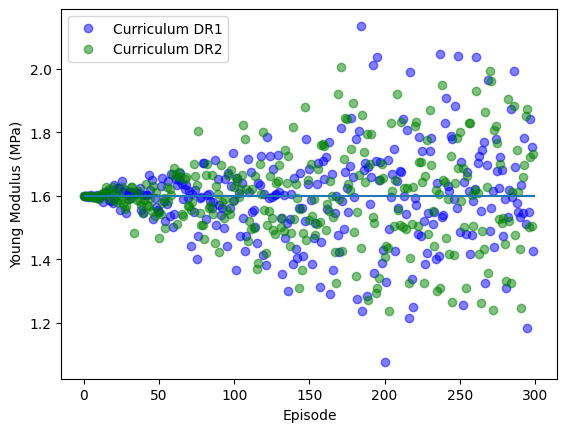

In [13]:
plt.plot(dr1_history['young_modulus'], 'o', color='blue', alpha=0.5, label='Curriculum DR1')
plt.plot(dr2_history['young_modulus'], 'o', color='green', alpha=0.5, label='Curriculum DR2')

plt.hlines(xmin=0, xmax=len(dr1_history['young_modulus']), y=dr1_history['young_modulus'][0])

plt.xlabel("Episode")
plt.ylabel("Young Modulus (MPa)")
plt.legend()
plt.show()

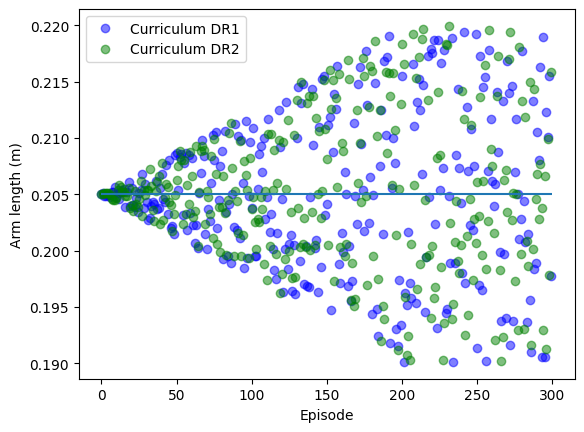

In [14]:
plt.plot(dr1_history['arm_length'], 'o', color='blue', alpha=0.5, label='Curriculum DR1')
plt.plot(dr2_history['arm_length'], 'o', color='green', alpha=0.5, label='Curriculum DR2')

plt.hlines(xmin=0, xmax=len(dr1_history['arm_length']), y=dr1_history['arm_length'][0])

plt.xlabel("Episode")
plt.ylabel("Arm length (m)")
plt.legend()
plt.show()

In [ ]:
# the curriculum works also for n-dimensional parameters
#gravity_vectors = np.array(dr1_history['gravity_vector'])

#plt.plot(gravity_vectors[:,0], 'o')
#plt.plot(gravity_vectors[:,1], 'o')
#plt.plot(gravity_vectors[:,2], 'o')